# 01 — Load samples and quality control
Reproduction of Boukhaled et al. 2022, *Nat Immunol* 23:1273–1283  
Track B: scRNA-seq (GEX from 10x Multiome, GSE199994), 10 samples: HD1–2, P1–P4 (high IRC), P5–P8 (low IRC)

## Step 6.1 — Setup: load packages and project path

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(tidyverse)
  library(patchwork)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)

## Step 6.2 — Read the sample sheet

In [2]:
ss <- read_csv(file.path(proj, "metadata/sample_sheet.csv"), show_col_types = FALSE)
ss

sample,group,donor_type
<chr>,<chr>,<chr>
HD1,HD,healthy
HD2,HD,healthy
P1,high_IRC,patient
P2,high_IRC,patient
P3,high_IRC,patient
P4,high_IRC,patient
P5,low_IRC,patient
P6,low_IRC,patient
P7,low_IRC,patient


## Step 6.3 — Load each sample and compute mitochondrial %

In [3]:
# Load each sample and compute mitochondrial %. We keep the samples as a list of separate objects rather than merging, because DoubletFinder must run on each sample individually. This may take a few minutes:
objs <- map(ss$sample, function(s) {
  counts <- Read10X(file.path(proj, "data", s))
  obj <- CreateSeuratObject(counts = counts, project = s)
  obj$sample <- s
  obj$group  <- ss$group[ss$sample == s]
  obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")
  obj
}) |> set_names(ss$sample)

objs

$HD1
An object of class Seurat 
36601 features across 7565 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$HD2
An object of class Seurat 
36601 features across 11952 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$P1
An object of class Seurat 
36601 features across 10845 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$P2
An object of class Seurat 
36601 features across 14493 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$P3
An object of class Seurat 
36601 features across 13010 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$P4
An object of class Seurat 
36601 features across 10787 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

$P5
An ob

## Step 6.4 — QC summary using the paper's thresholds

In [8]:
qc_summary <- qc |>
  group_by(sample, group) |>
  summarise(cells        = n(),
            median_genes = median(nFeature_RNA),
            median_umi   = median(nCount_RNA),
            median_mt    = round(median(percent.mt), 2),
            n_pass       = sum(pass),
            pct_kept     = round(100 * mean(pass), 1),
            .groups = "drop")
qc_summary
write_csv(qc_summary, file.path(proj, "results/tables/01_qc_summary_prefilter.csv"))

sample,group,cells,median_genes,median_umi,median_mt,n_pass,pct_kept
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
HD1,HD,7565,2033.0,4412.0,5.82,7493,99.0
HD2,HD,11952,2068.0,4194.0,4.64,11744,98.3
P1,high_IRC,10845,2245.0,5049.0,6.14,9915,91.4
P2,high_IRC,14493,1909.0,4022.0,5.01,13838,95.5
P3,high_IRC,13010,1996.5,4317.0,6.62,12660,97.3
P4,high_IRC,10787,1984.0,4513.0,5.27,10269,95.2
P5,low_IRC,2992,1298.0,2545.0,11.42,2820,94.3
P6,low_IRC,9948,1678.0,3454.5,10.86,9654,97.0
P7,low_IRC,9704,1960.5,3965.5,8.81,9282,95.7


## Step 6.5 — QC violin plots (pre-filter)

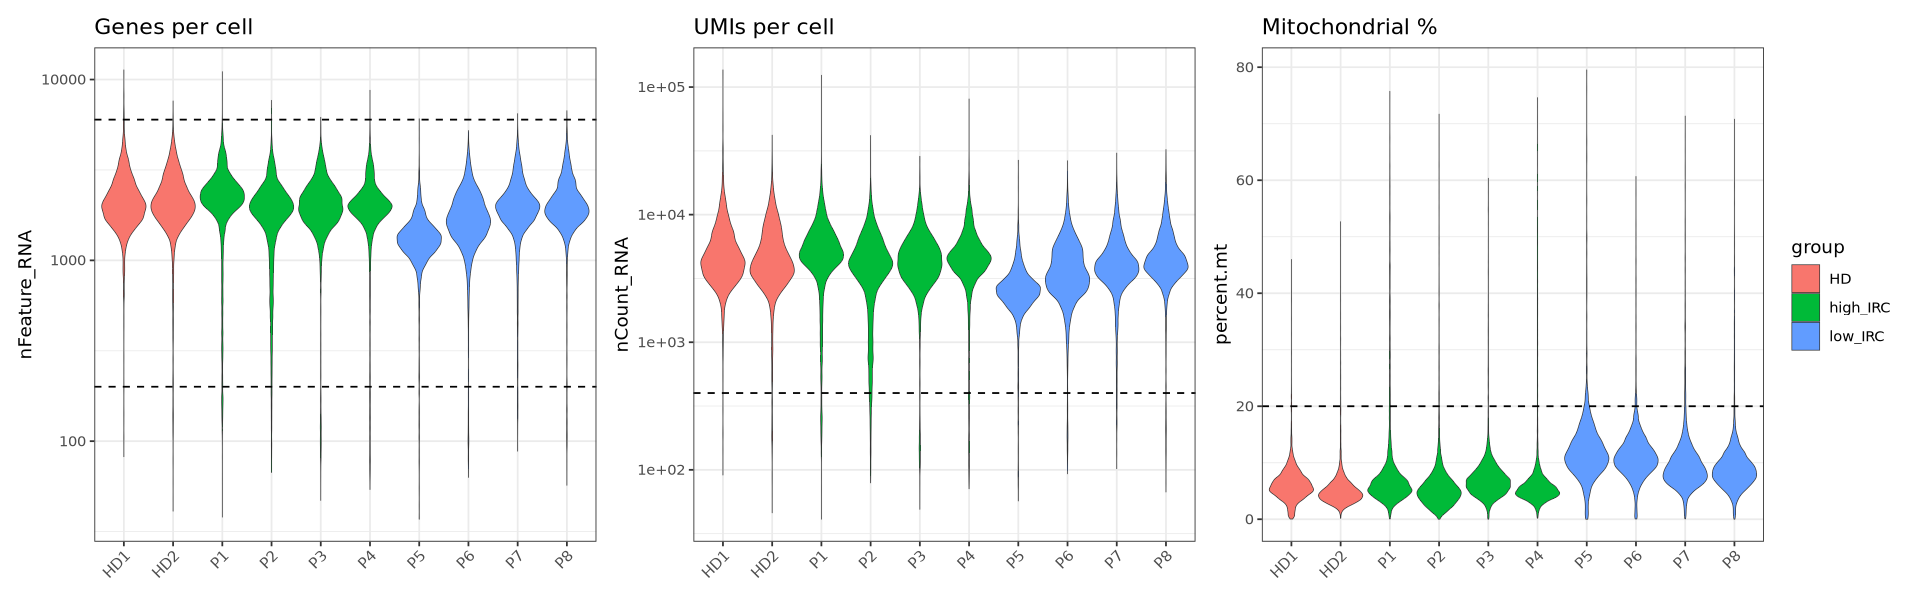

In [5]:
options(repr.plot.width = 16, repr.plot.height = 5)

base <- function(y, title) {
  ggplot(qc, aes(sample, .data[[y]], fill = group)) +
    geom_violin(scale = "width", linewidth = 0.2) +
    labs(title = title, x = NULL) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}
p1 <- base("nFeature_RNA", "Genes per cell") + scale_y_log10() +
  geom_hline(yintercept = c(200, 6000), linetype = "dashed")
p2 <- base("nCount_RNA", "UMIs per cell") + scale_y_log10() +
  geom_hline(yintercept = 400, linetype = "dashed")
p3 <- base("percent.mt", "Mitochondrial %") +
  geom_hline(yintercept = 20, linetype = "dashed")

qc_plot <- (p1 | p2 | p3) + plot_layout(guides = "collect")
qc_plot
ggsave(file.path(proj, "figures/trackB/01_qc_violins_prefilter.png"),
       qc_plot, width = 16, height = 5, dpi = 150)

### QC observations and decision
- Overall quality good: most cells 1,500–3,000 genes, 3,000–6,000 UMIs, mito <10%.
- P5 is the weakest sample: fewest cells (2,992), lower genes/UMIs, higher mito (~12% median).
- Low-IRC patients (P5–P8) have systematically higher mito % than high-IRC and HD samples.
  Possible technical confounder for low-IRC pathway findings (OXPHOS, translation; Fig 5i).
- Median mito %: HD 4.6–5.8, high IRC 5.0–6.6, low IRC 8.5–11.4.
- Decision: use the paper's thresholds (genes 200–6,000, UMIs >400, mito <20%) for fidelity.
  A stricter mito cutoff would remove disproportionately many low-IRC cells.
- After filtering: 97,142 cells (HD 19,237; high IRC 46,682; low IRC 31,223). P5 retains 2,820.
- Follow-up: test mito % within CD4 Teff; rerun key DE/GSEA with mito % as covariate.

## Step 7.1 — Apply the paper's QC filter

In [6]:
objs_filt <- map(objs, ~ subset(.x, subset = nFeature_RNA > 200 & nFeature_RNA < 6000 &
                                          nCount_RNA > 400 & percent.mt < 20))

cells_after <- tibble(sample = names(objs_filt),
                      cells_after = map_int(objs_filt, ncol))

qc_summary |>
  mutate(sample = as.character(sample)) |>
  left_join(cells_after, by = "sample") |>
  mutate(pct_removed = round(100 * (cells - cells_after) / cells, 1))

sample,group,cells,median_genes,median_umi,median_mt,pass,pct_kept,cells_after,pct_removed
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>
HD1,HD,7565,2033.0,4412.0,5.82,7493,749300,7493,1.0
HD2,HD,11952,2068.0,4194.0,4.64,11744,1174400,11744,1.7
P1,high_IRC,10845,2245.0,5049.0,6.14,9915,991500,9915,8.6
P2,high_IRC,14493,1909.0,4022.0,5.01,13838,1383800,13838,4.5
P3,high_IRC,13010,1996.5,4317.0,6.62,12660,1266000,12660,2.7
P4,high_IRC,10787,1984.0,4513.0,5.27,10269,1026900,10269,4.8
P5,low_IRC,2992,1298.0,2545.0,11.42,2820,282000,2820,5.7
P6,low_IRC,9948,1678.0,3454.5,10.86,9654,965400,9654,3.0
P7,low_IRC,9704,1960.5,3965.5,8.81,9282,928200,9282,4.3


## Step 7.2 — Save filtered objects

In [7]:
saveRDS(objs_filt, file.path(proj, "results/objects/01_objs_filtered.rds"))
rm(objs); gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4298432,229.6,7152628,382.0,7152628,382.0
Vcells,313536613,2392.1,773293565,5899.8,658913588,5027.2
